# Changing resolution dispersion

By default, the resolution dispersion, which indicates the footprint of point spread function (PSF) on the detector, is 2, hence assuming the Nyquist sampling.

The Nyquist sampling is optimal:
- lower the PSF is under-sampled, hence impossible to fully model without prior knowledge ;
- higher the PSF is over-sampled, hence the light is dispersed in too many pixel inducing loss in signal to noise.

Depending on the kind of Spectrograph, this PSF footprint on the detector is connected to the actual optical PSF from the telescope (for slicer) or not (for lens array).

## For a Slicer

For a slicer, the optical PSF in the slicer plan is split into sub-images (on per slice). Each of these images is dispersed in the direction perpendicular to the slicer width. In `slicersim`, "x" (*dim "0"*) is the "x-slice" direction, hence the dispersion direction ; "y" (*dim "1"*) is the "slice" direction. 

Hence, for a slicer, *the resolution dispersion* affects:
   - the optical PSF along the "y" direction (i.e. the sub-image seen by the detector)
   - the line spread function along the "x" direction.

## For a multi-lense array

For a lense array, the information related to the optical PSF is basically lost after the lenses, which focuses the spatial element into a point into the dispersor plan. This point is dispersed in the detector forming a 2d trace (aka a "spectrogram").

Hence, for a mla, *the resolution dispersion* affects:
   - the x-dispersion profile along the "y" direction
   - the line spread function along the "x" direction.



## Change resolution dispersion

Let's access the `Spectrograph` object associated to a SN Ia

In [1]:
import slicersim

In [2]:
snia = slicersim.LazuliSN()
spectro = snia.simulation.spectrograph

now, we will force the `dispersion_resolution` to be 2 (optical).
Note that `lbda` is affected by this parameter, so doing so changes lbda.

In [3]:
changed_entries = spectro.update(dispersion_resolution=2)
print(changed_entries)

['lbda', 'meta']


and get the "PSF cube"

In [4]:
psf_nyquist = spectro.get_spatial_psf(profile="airy")

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

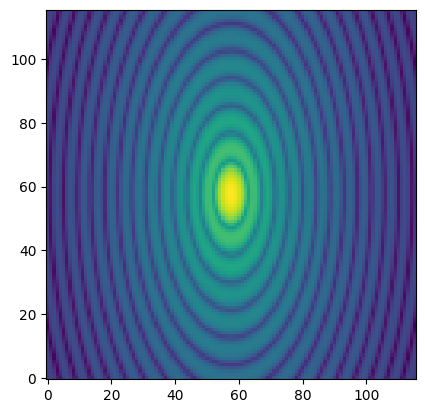

In [6]:
fig, ax = plt.subplots()

norm = colors.LogNorm()

# Let's show the slice the closest to 5000A
index_lbda_5000 = np.argmin((spectro.lbda-5000)**2)
ax.imshow(psf_nyquist[index_lbda_5000], norm=norm, origin="lower")

Now let's assume a dispersion resolution of 2.5. 

In [7]:
changed_entries = spectro.update(dispersion_resolution=2.5)
psf_oversampled = spectro.get_spatial_psf(profile="airy")

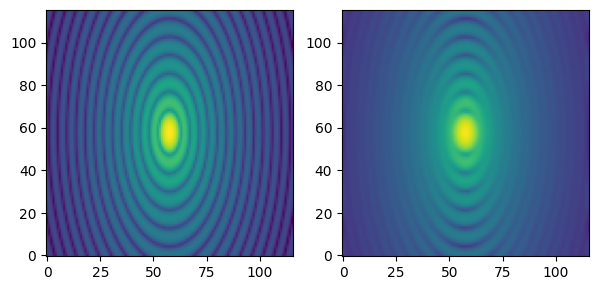

In [8]:
fig, (ax, axo) = plt.subplots(ncols=2, figsize=(7,4))

norm = colors.LogNorm()

# Let's show the slice the closest to 5000A
# remark, this index is not the same for psf_oversampled and psf_nyquist
# as the dispersion_resolution affects the lsf, so more lbda bins if oversampled.

# Nyquist
ax.imshow(psf_nyquist[index_lbda_5000], norm=norm, origin="lower")

# Nyquist
index_lbda_oversampled_5000 = np.argmin((spectro.lbda-5000)**2)
axo.imshow(psf_oversampled[index_lbda_oversampled_5000], norm=norm, origin="lower")